<a href="https://colab.research.google.com/github/Lornatt88/maai901-vision-project/blob/main/notebooks/04_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Loading everything**

In [1]:
import os
import numpy as np
import pandas as pd
from google.colab import drive
from sklearn.metrics import balanced_accuracy_score

drive.mount("/content/drive")
save_dir = "/content/drive/MyDrive/maai901_skin"

test_df = pd.read_csv(os.path.join(save_dir, "test.csv")).reset_index(drop=True)
classes = ["nv", "bkl", "mel", "bcc"]
class_to_idx = {c: i for i, c in enumerate(classes)}

probs = np.load(os.path.join(save_dir, "swin_finetuned_test_probs.npy"))

def predict_with_threshold(probs, t):
    preds = probs.argmax(1).copy()
    cancer_prob = probs[:, 2] + probs[:, 3]
    flag = cancer_prob >= t
    preds[flag] = np.where(probs[flag, 2] >= probs[flag, 3], 2, 3)
    return preds

df = test_df.copy()
df["y"] = df["dx"].map(class_to_idx)
df["pred"] = probs.argmax(1)
df["pred_t"] = predict_with_threshold(probs, 0.25)

print("Test images:", len(df), "| Predictions loaded:", len(probs))
print("Balanced accuracy check:", round(balanced_accuracy_score(df["y"], df["pred"]), 3))

Mounted at /content/drive
Test images: 544 | Predictions loaded: 544
Balanced accuracy check: 0.822


### **Grouping by results**

**What it does:**
- Sorts patients into 3 age bands (under 40/ 40 to 59/ 60 and over).
- Keeps the 5 most common body locations and groups the rest as "other" so no group is tiny.
- For each group: counts images and cancers, then calculates balanced accuracy, cancers caught (normal and with 0.25) and false alarms.


In [2]:
df["age_group"] = pd.cut(df["age"], bins=[0, 39, 59, 120], labels=["Under 40", "40 to 59", "60 and over"])
df["age_group"] = df["age_group"].astype(str).replace("nan", "Unknown")

top_locations = df["localization"].value_counts().index[:5]
df["body_location"] = df["localization"].where(df["localization"].isin(top_locations), "other")

def group_report(col):
    rows = []
    for group, d in df.groupby(col):
        cancer = d["y"].isin([2, 3])
        harmless = ~cancer
        rows.append({
            "Group": group,
            "Images": len(d),
            "Cancers": int(cancer.sum()),
            "Balanced acc": balanced_accuracy_score(d["y"], d["pred"]),
            "Cancer caught": d.loc[cancer, "pred"].isin([2, 3]).mean() if cancer.sum() else np.nan,
            "Cancer caught (0.25)": d.loc[cancer, "pred_t"].isin([2, 3]).mean() if cancer.sum() else np.nan,
            "Harmless flagged (0.25)": d.loc[harmless, "pred_t"].isin([2, 3]).mean() if harmless.sum() else np.nan,
        })
    return pd.DataFrame(rows).round(3)

for col, title in [("sex", "BY SEX"), ("age_group", "BY AGE"), ("body_location", "BY BODY LOCATION")]:
    table = group_report(col)
    table.to_csv(os.path.join(save_dir, f"bias_{col}.csv"), index=False)
    print(f"\n===== {title} =====")
    display(table)


===== BY SEX =====


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


,Group,Images,Cancers,Balanced acc,Cancer caught,Cancer caught (0.25),Harmless flagged (0.25)
0,female,212,73,0.827,0.781,0.890,0.230
1,male,328,158,0.825,0.911,0.968,0.294
2,unknown,4,0,1.000,NaN,NaN,0.000



===== BY AGE =====


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


,Group,Images,Cancers,Balanced acc,Cancer caught,Cancer caught (0.25),Harmless flagged (0.25)
0,40 to 59,184,68,0.860,0.868,0.897,0.181
1,60 and over,294,145,0.862,0.903,0.979,0.262
2,Under 40,60,18,0.508,0.611,0.833,0.524
3,Unknown,6,0,1.000,NaN,NaN,0.000



===== BY BODY LOCATION =====


,Group,Images,Cancers,Balanced acc,Cancer caught,Cancer caught (0.25),Harmless flagged (0.25)
0,back,144,77,0.795,0.909,0.987,0.358
1,face,67,23,0.752,0.783,0.870,0.227
2,lower extremity,100,45,0.837,0.867,0.911,0.218
3,other,124,54,0.844,0.907,0.963,0.286
4,trunk,52,6,0.873,0.833,0.833,0.174
5,upper extremity,57,26,0.775,0.769,0.923,0.258


### **Checking the training data behind the bias**

In [3]:
train_df = pd.read_csv(os.path.join(save_dir, "train.csv"))
train_df["cancer"] = train_df["dx"].isin(["mel", "bcc"])
train_df["age_group"] = pd.cut(train_df["age"], bins=[0, 39, 59, 120], labels=["Under 40", "40 to 59", "60 and over"])
train_df["age_group"] = train_df["age_group"].astype(str).replace("nan", "Unknown")

for col, title in [("sex", "TRAINING DATA BY SEX"), ("age_group", "TRAINING DATA BY AGE")]:
    summary = train_df.groupby(col).agg(
        Images=("dx", "size"),
        Cancers=("cancer", "sum"),
    )
    summary["Cancer share"] = (summary["Cancers"] / summary["Images"]).round(3)
    summary["% of all training cancers"] = (summary["Cancers"] / summary["Cancers"].sum() * 100).round(1)
    summary.to_csv(os.path.join(save_dir, f"train_composition_{col}.csv"))
    print(f"\n===== {title} =====")
    display(summary)


===== TRAINING DATA BY SEX =====


,Images,Cancers,Cancer share,% of all training cancers
sex,,,,
female,1069,437,0.409,38.3
male,1486,705,0.474,61.7
unknown,11,0,0.000,0.0



===== TRAINING DATA BY AGE =====


,Images,Cancers,Cancer share,% of all training cancers
age_group,,,,
40 to 59,866,323,0.373,28.3
60 and over,1445,760,0.526,66.5
Under 40,240,59,0.246,5.2
Unknown,15,0,0.000,0.0


### **Sample outputs figure**

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.


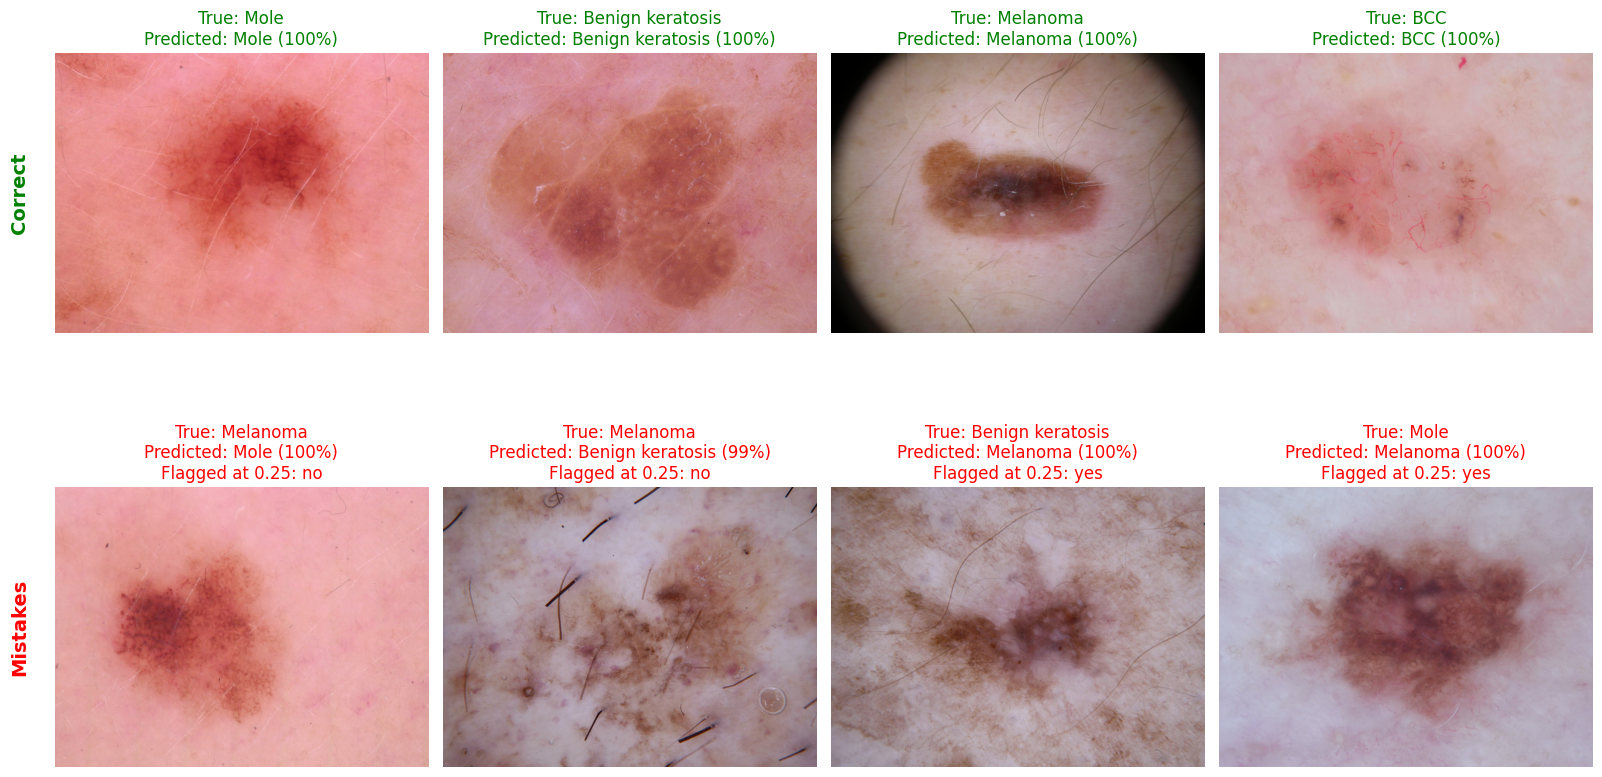

In [4]:
import kagglehub
import matplotlib.pyplot as plt
from PIL import Image

kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

short = {0: "Mole", 1: "Benign keratosis", 2: "Melanoma", 3: "BCC"}
df["conf"] = probs.max(1)
correct = df[df["y"] == df["pred"]]
wrong = df[df["y"] != df["pred"]]

picks_correct = [correct[correct["y"] == k].sort_values("conf", ascending=False).iloc[0] for k in range(4)]

mistake_types = [(2, 0), (2, 1), (1, 2), (0, 2)]
picks_wrong = []
for true_k, pred_k in mistake_types:
    sub = wrong[(wrong["y"] == true_k) & (wrong["pred"] == pred_k)]
    if len(sub):
        picks_wrong.append(sub.sort_values("conf", ascending=False).iloc[0])

fig, axes = plt.subplots(2, 4, figsize=(16, 9.5))
for row, picks in [(0, picks_correct), (1, picks_wrong)]:
    for j in range(4):
        ax = axes[row, j]
        ax.axis("off")
        if j < len(picks):
            r = picks[j]
            ax.imshow(Image.open(r["path"]))
            title = f"True: {short[r['y']]}\nPredicted: {short[r['pred']]} ({r['conf']:.0%})"
            if row == 1:
                flagged = "yes" if r["pred_t"] in [2, 3] else "no"
                title += f"\nFlagged at 0.25: {flagged}"
            ax.set_title(title, color="green" if row == 0 else "red", fontsize=12)

axes[0, 0].text(-0.12, 0.5, "Correct", transform=axes[0, 0].transAxes, rotation=90,
                va="center", fontsize=14, fontweight="bold", color="green")
axes[1, 0].text(-0.12, 0.5, "Mistakes", transform=axes[1, 0].transAxes, rotation=90,
                va="center", fontsize=14, fontweight="bold", color="red")

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "sample_predictions.png"), dpi=150, bbox_inches="tight")
plt.show()